In [1]:
!pip install optuna

In [2]:
# base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# geo
from geopy.distance import geodesic

# torch
import torch

# sklearn — pré-processamento
from sklearn.preprocessing import StandardScaler, LabelEncoder

# sklearn — modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

# sklearn — seleção de modelos
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, train_test_split

# sklearn — métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score,
)

# sklearn — imbalanced
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler

# xgboost
from xgboost import XGBClassifier

# optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
!pip install kaggle

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bianewman","key":"feb4de37ad41d44d3bec63ae62c87a8e"}'}

In [5]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d kartik2112/fraud-detection

Dataset URL: https://www.kaggle.com/datasets/kartik2112/fraud-detection
License(s): CC0-1.0
fraud-detection.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
!unzip fraud-detection.zip

Archive:  fraud-detection.zip
replace fraudTest.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fraudTest.csv           
replace fraudTrain.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fraudTrain.csv          


In [8]:
train = pd.read_csv('fraudTrain.csv', index_col = 0)
test = pd.read_csv('fraudTest.csv',index_col = 0)

In [9]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (1296675, 22)
Test shape: (555719, 22)


In [10]:
df_full = pd.concat([train, test], axis=0)
#df_full = build_features(df_full)
print(f"Full data shape: {df_full.shape}")

Full data shape: (1852394, 22)


In [11]:
def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371  # raio da Terra em km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

In [12]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
  #Cria features de data/hora, idade e distância geográfica
    df = df.copy()
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
    df["dob"]                   = pd.to_datetime(df["dob"])

    df["hour"]        = df["trans_date_trans_time"].dt.hour
    df["day"]         = df["trans_date_trans_time"].dt.day
    df["month"]       = df["trans_date_trans_time"].dt.month
    df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
    df["is_weekend"]  = df["day_of_week"].isin([5, 6]).astype(int)
    df["is_night"]    = df["hour"].between(0, 6).astype(int)
    df["age"]         = (df["trans_date_trans_time"] - df["dob"]).dt.days // 365

    df["distance"] = haversine_vectorized(
        df["lat"], df["long"], df["merch_lat"], df["merch_long"]
    )
    return df

#EDA

In [13]:
df_eda = build_features(df_full)

In [14]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1852394 entries, 0 to 555718
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   cc_num                 int64  
 2   merchant               object 
 3   category               object 
 4   amt                    float64
 5   first                  object 
 6   last                   object 
 7   gender                 object 
 8   street                 object 
 9   city                   object 
 10  state                  object 
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    object 
 16  dob                    object 
 17  trans_num              object 
 18  unix_time              int64  
 19  merch_lat              float64
 20  merch_long             float64
 21  is_fraud               int64  
dtypes: float64(5), int64(5),

In [15]:
df_full.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


DATA CLEANING

In [16]:
# Não há nenhum valor faltante
print(f"Total de linhas duplicadas: {df_full.isnull().sum()}")

Total de linhas duplicadas: trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [17]:
print(f"Total de linhas duplicadas: {df_full.duplicated().sum()}")

Total de linhas duplicadas: 0


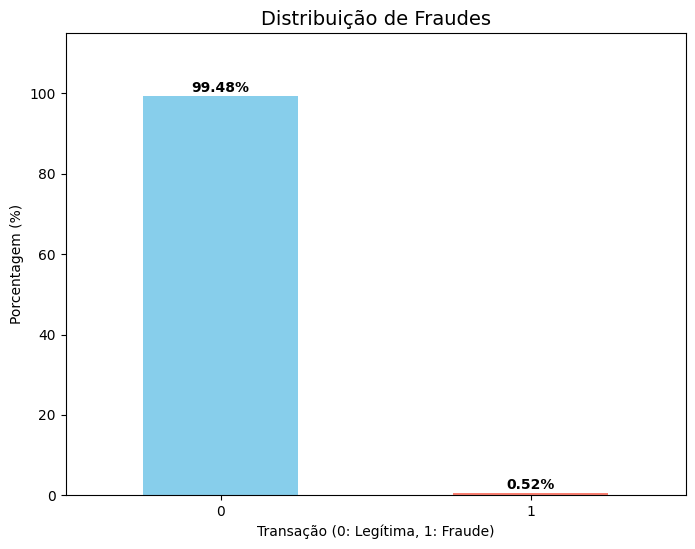

is_fraud
0    1842743
1       9651
Name: count, dtype: int64


In [18]:
# Calcula a porcentagem
df_percent = df_full["is_fraud"].value_counts(normalize=True) * 100

# Gráfico de barras
ax = df_percent.plot(kind='bar', color=['skyblue', 'salmon'], figsize=(8, 6))
for i, v in enumerate(df_percent):
    ax.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.title('Distribuição de Fraudes', fontsize=14)
plt.ylabel('Porcentagem (%)')
plt.xlabel('Transação (0: Legítima, 1: Fraude)')
plt.xticks(rotation=0)
plt.ylim(0, 115)
plt.show()

# Calcula a quantidade de fraude e não fraude
print(df_full["is_fraud"].value_counts())


In [19]:
# valor total de transações por categoria
df_full['category'].value_counts()

,count
category,
gas_transport,188029
grocery_pos,176191
home,175460
shopping_pos,166463
kids_pets,161727
shopping_net,139322
entertainment,134118
food_dining,130729
personal_care,130085


In [20]:
# Valor da transação
stats_valor = df_full.groupby('is_fraud')['amt'].describe()
print(stats_valor)

              count        mean         std   min      25%     50%      75%  \
is_fraud                                                                      
0         1842743.0   67.651278  153.548108  1.00    9.610   47.24   82.560   
1            9651.0  530.661412  391.028873  1.06  240.075  390.00  902.365   

               max  
is_fraud            
0         28948.90  
1          1376.04  




*   A fraude, em média, é 7,8 vezes maior que uma transação normal. Isso indica que o fraudador está tentando extrair o máximo de valor possível em poucas operações, em vez de passar despercebido com valores pequenos.
*   Legítimo (25% a 75%): A maioria das pessoas gasta entre $9,61e $82.56
*   Fraude (25% a 75%): A maioria das fraudes ocorre entre $240,07 e $902.36, ou seja, Se uma transação passa de $200, a probabilidade estatística de ser fraude aumenta drasticamente
* valor máximo de uma fraude é muito menor que o valor máximo de uma compra legítima. Isso é um comportamento comum em simuladores: o fraudador evita valores altos pois sabe que isso bloqueia o cartão instantaneamente por segurança bancária.






In [21]:
# Calcula a taxa de fraude por categoria e compara com a média global
taxa_global = df_full['is_fraud'].mean()
cat_stats = df_full.groupby('category')['is_fraud'].agg(['mean', 'count'])
cat_stats['risk_factor'] = cat_stats['mean'] / taxa_global

print(cat_stats.sort_values(by='risk_factor', ascending=False))

                    mean   count  risk_factor
category                                     
shopping_net    0.015927  139322     3.057023
misc_net        0.013039   90654     2.502601
grocery_pos     0.012645  176191     2.427127
shopping_pos    0.006344  166463     1.217607
gas_transport   0.004106  188029     0.788050
misc_pos        0.002819  114229     0.541054
grocery_net     0.002697   64878     0.517728
travel          0.002692   57956     0.516639
personal_care   0.002229  130085     0.427890
entertainment   0.002177  134118     0.417885
kids_pets       0.001880  161727     0.360788
food_dining     0.001568  130729     0.300984
home            0.001510  175460     0.289887
health_fitness  0.001510  122553     0.289740


risk_factor > 1: shopping_net (3x mais fraude), misc_net, grocery_pos e shopping_pos
* compras online estão no topo (o que condiz com a realidade)
* categorias do dia a dia/físicas têm menor risco, pois envolvem presença física, valor menor.



In [22]:
# Quantas categorias respondem por 80% das fraudes?
fraudes_por_cat = df_full[df_full['is_fraud'] == 1]['category'].value_counts(normalize=True).cumsum()
print(fraudes_por_cat)

category
grocery_pos       0.230857
shopping_net      0.460781
misc_net          0.583256
shopping_pos      0.692674
gas_transport     0.772666
misc_pos          0.806030
kids_pets         0.837530
entertainment     0.867786
personal_care     0.897834
home              0.925293
food_dining       0.946534
health_fitness    0.965703
grocery_net       0.983836
travel            1.000000
Name: proportion, dtype: float64


* apenas 6 categorias explicam 80% das fraudes
* mas nem sempre quem tem mais fraude é o mais arriscado
* exemplo: embora a chance de uma transação em mercado (grocery_pos) ser fraude seja menor do que em uma loja online, o volume de transações em mercados é tão alto que, no fim das contas, é onde ocorre o maior número de crimes.
* Por risco (probabilidade)
foca onde é mais perigoso
ex: shopping_net
* Por impacto total
foca onde mais fraudes acontecem
ex: grocery_pos

In [23]:
top_cats = ['grocery_pos', 'shopping_net', 'misc_net']

for cat in top_cats:
    fraud_subset = df_eda[(df_eda['category'] == cat) & (df_eda['is_fraud'] == 1)]

    if not fraud_subset.empty:
        peak_hour = fraud_subset['hour'].mode()[0]
        print(f"Pico de fraude em {cat}: {peak_hour}h")

Pico de fraude em grocery_pos: 1h
Pico de fraude em shopping_net: 22h
Pico de fraude em misc_net: 23h


* fraude em compras online acontecem a partir do fim da noite/início da madrugada
 * grocery_pos 1hr da manhã foge do padrão, então, se acontecer, pode ser uma fraude

In [24]:
# Pico global legítimo
peak_legit = df_eda[df_eda['is_fraud'] == 0]['hour'].mode()[0]

# Pico global fraude
peak_fraud = df_eda[df_eda['is_fraud'] == 1]['hour'].mode()[0]

print("Pico Legítimo (Global):", peak_legit, "h")
print("Pico Fraude (Global):", peak_fraud, "h")

Pico Legítimo (Global): 16 h
Pico Fraude (Global): 22 h


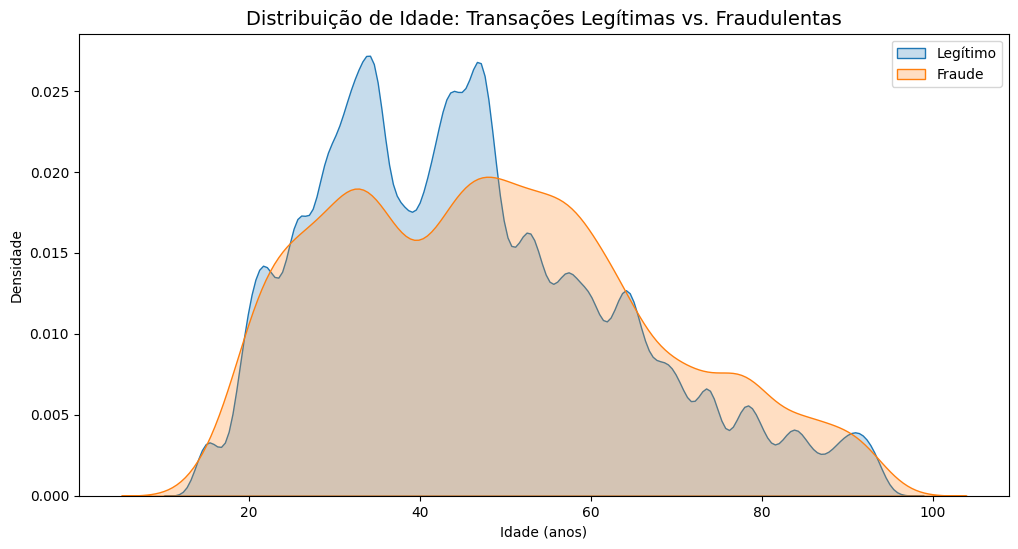

In [25]:
plt.figure(figsize=(12, 6))

# Densidade para transações legítimas
sns.kdeplot(df_eda[df_eda['is_fraud'] == 0]['age'], label='Legítimo', fill=True)

# Densidade para fraudes
sns.kdeplot(df_eda[df_eda['is_fraud'] == 1]['age'], label='Fraude', fill=True)

plt.title('Distribuição de Idade: Transações Legítimas vs. Fraudulentas', fontsize=14)
plt.xlabel('Idade (anos)')
plt.ylabel('Densidade')
plt.legend()
plt.show()

* A Figura X apresenta a estimativa de densidade de kernel (KDE) para a variável
'Idade'. Embora as distribuições de transações legítimas e fraudulentas compartilhem picos semelhantes (notadamente aos 35 e 50 anos), há um descolamento das curvas a partir dos 55 anos. Nesta zona, a densidade de fraudes supera a de transações lícitas, sugerindo que usuários em faixas etárias mais avançadas apresentam um perfil de risco ligeiramente elevado neste dataset (alvos para esses golpes). Contudo, a alta sobreposição das áreas indica que a idade deve ser utilizada como uma feature de suporte, e não como um preditor isolado.
* Além disso, tem um pico entre 30 e 50 anos, ou seja, demografia de pessoas portadoras de cartão de crédito

In [26]:
# Faixas etárias
bins = [0, 18, 30, 50, 65, 100]
labels = ['Menor de idade', 'Jovem Adulto', 'Adulto', 'Sênior', 'Idoso']

df_eda['age_group'] = pd.cut(df_eda['age'], bins=bins, labels=labels)

# Calculando o risco por faixa (taxa de fraude)
age_risk = (
    df_eda
    .groupby('age_group', observed=False)['is_fraud']
    .mean()
    .sort_values(ascending=False) * 100
)

print(age_risk)

age_group
Idoso             0.671967
Sênior            0.656866
Menor de idade    0.534012
Jovem Adulto      0.506211
Adulto            0.419414
Name: is_fraud, dtype: float64


* A probablidade de uma transação ser fraudulenta é maior em idosos

In [27]:
print(df_eda.groupby('is_fraud')['distance'].mean())


is_fraud
0    76.110969
1    76.256233
Name: distance, dtype: float64


In [28]:
print(df_eda.groupby('is_fraud')['city_pop'].mean())

is_fraud
0    88636.579284
1    89998.422961
Name: city_pop, dtype: float64


população de cidade é de baixa variância entre as classes, ou seja, não denuncia fraude tão facilmente sozinha

<Axes: xlabel='gender', ylabel='is_fraud'>

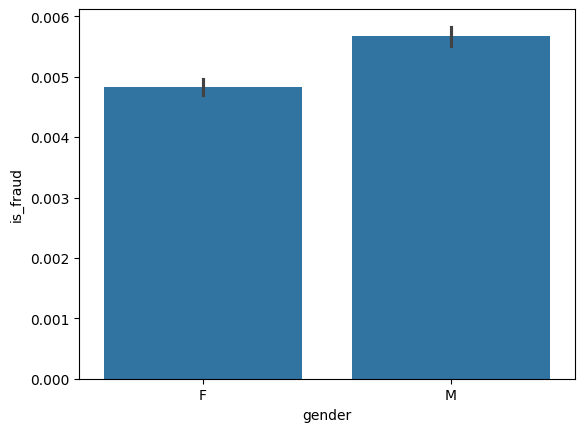

In [29]:
sns.barplot(x='gender', y='is_fraud', data=df_full)

* tem maior probabilidade de ser fraude por homem do que por mulher

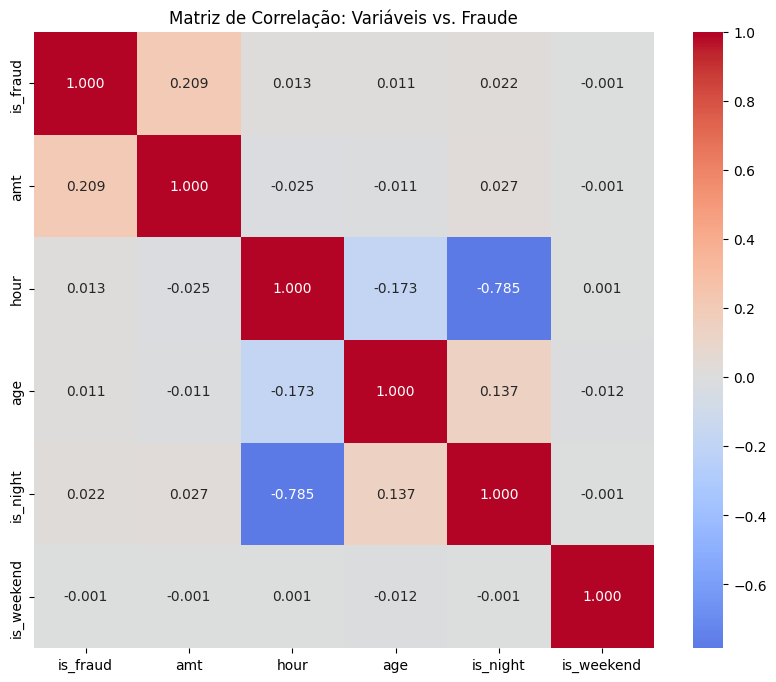

In [30]:
# Matriz de correlação das colunas numéricas
cols_para_correlacao = ['is_fraud', 'amt', 'hour', 'age', 'is_night', 'is_weekend']

corr = df_eda[cols_para_correlacao].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".3f", center=0)
plt.title('Matriz de Correlação: Variáveis vs. Fraude')
plt.show()

* a maior correlação é amount e is_fraud, ou seja, o principal fator pra apontar se é fraude
* is_night tem maior correlação do que hour, ou seja, fraude tem uma dependência maior a noite
* a ocorrência de fraude não depende de ser final de semana, então, posso despriorizar essa feature

# Limpeza Inicial do dataset

In [31]:
df = build_features(train)

In [32]:
X = df.drop(columns=[
    "is_fraud", "trans_date_trans_time", "dob",
    "cc_num", "first", "last", "street", "zip", "unix_time", "lat", "long", "merch_lat", "trans_num","merch_long",
])
y = df["is_fraud"]

In [33]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 16 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   merchant     1296675 non-null  object 
 1   category     1296675 non-null  object 
 2   amt          1296675 non-null  float64
 3   gender       1296675 non-null  object 
 4   city         1296675 non-null  object 
 5   state        1296675 non-null  object 
 6   city_pop     1296675 non-null  int64  
 7   job          1296675 non-null  object 
 8   hour         1296675 non-null  int32  
 9   day          1296675 non-null  int32  
 10  month        1296675 non-null  int32  
 11  day_of_week  1296675 non-null  int32  
 12  is_weekend   1296675 non-null  int64  
 13  is_night     1296675 non-null  int64  
 14  age          1296675 non-null  int64  
 15  distance     1296675 non-null  float64
dtypes: float64(2), int32(4), int64(4), object(6)
memory usage: 148.4+ MB


In [34]:
# pipeline_utils Funções compartilhadas entre Random Forest e XGBoost.
#   from pipeline_utils import (
#       target_encoding_oof,
#       compute_logistic_stats,
#       apply_logistic_features,
#       preprocess_fold,
#       best_threshold,
#   )
# ─────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────
# 1. TARGET ENCODING OOF
# ─────────────────────────────────────────────────────────────
def target_encoding_oof(X_tr, y_tr, col, n_splits=5, k=100):
    """
    Retorna o array OOF encoded para X_tr e o mapping final
    (treinado no treino completo) para aplicar no val/test.
    Sem leakage: cada linha é encoded com dados que não a incluem.
    """
    global_mean   = y_tr.mean()
    train_encoded = np.zeros(len(X_tr))

    kf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )

    for fold_tr_idx, fold_val_idx in kf.split(X_tr, y_tr):

        X_fold = X_tr.iloc[fold_tr_idx]
        y_fold = y_tr.iloc[fold_tr_idx]

        temp           = X_fold[[col]].copy()
        temp["target"] = y_fold.values

        stats = temp.groupby(col)["target"].agg(["count", "mean"])
        stats["smooth"] = (
            (stats["count"] * stats["mean"] + k * global_mean)
            / (stats["count"] + k)
        )

        encoded = (
            X_tr[col]
            .iloc[fold_val_idx]
            .map(stats["smooth"])
            .fillna(global_mean)
        )
        train_encoded[fold_val_idx] = encoded.values

    # mapping final com todo o treino (para val e test)
    temp_full           = X_tr[[col]].copy()
    temp_full["target"] = y_tr.values

    stats_full = temp_full.groupby(col)["target"].agg(["count", "mean"])
    stats_full["smooth"] = (
        (stats_full["count"] * stats_full["mean"] + k * global_mean)
        / (stats_full["count"] + k)
    )

    mapping = stats_full["smooth"]

    return pd.Series(train_encoded, index=X_tr.index), mapping


# ─────────────────────────────────────────────────────────────
# 2. FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────
def compute_logistic_stats(df_tr):
    """
    Aprende todas as estatísticas de grupo apenas no treino.
    Retorna um dicionário de artefatos para uso em apply_logistic_features.
    """
    stats = {}

    stats["cat_mean"]  = df_tr.groupby("category")["amt"].mean()
    stats["cat_std"]   = df_tr.groupby("category")["amt"].std().fillna(0)
    stats["dist_mean"] = df_tr.groupby("category")["distance"].mean()
    stats["dist_std"]  = df_tr.groupby("category")["distance"].std().fillna(0)

    stats["amt_q90"]         = df_tr["amt"].quantile(0.90)
    stats["distance_median"] = df_tr["distance"].median()

    # cat_hour_mean: média de amt por (categoria × faixa horária)
    df_tmp = df_tr.copy()
    df_tmp["hour_bin"] = pd.cut(
        df_tmp["hour"],
        bins=[0, 6, 12, 18, 24],
        labels=[0, 1, 2, 3],
    )
    stats["cat_hour_mean"] = (
        df_tmp
        .groupby(["category", "hour_bin"], observed=True)["amt"]
        .mean()
    )

    return stats


def apply_logistic_features(df, stats):
    """
    Aplica features usando estatísticas externas (do treino).
    Nunca recalcula estatísticas com os dados recebidos.
    """
    df = df.copy()

    # transformações logarítmicas
    df["log_amount"]   = np.log1p(df["amt"])
    df["log_distance"] = np.log1p(df["distance"])

    # z-score e ratio por categoria
    cat_mean = df["category"].map(stats["cat_mean"])
    cat_std  = df["category"].map(stats["cat_std"])

    df["amt_zscore_cat"]     = (df["amt"] - cat_mean) / (cat_std + 1e-8)
    df["amt_ratio_category"] = df["amt"] / (cat_mean + 1e-8)

    # z-score por categoria × faixa horária
    df["hour_bin"] = pd.cut(
        df["hour"],
        bins=[0, 6, 12, 18, 24],
        labels=[0, 1, 2, 3],
    )
    idx = pd.MultiIndex.from_arrays([df["category"], df["hour_bin"]])
    cat_hour_mean_vals = (
        idx
        .map(stats["cat_hour_mean"])
        .to_series(index=df.index)
        .fillna(stats["cat_mean"].mean())
    )
    df["amt_zscore_cat_hour"] = (df["amt"] - cat_hour_mean_vals) / (cat_std + 1e-8)
    df.drop(columns=["hour_bin"], inplace=True)

    # z-score de distância por categoria
    dist_mean = df["category"].map(stats["dist_mean"])
    dist_std  = df["category"].map(stats["dist_std"])
    df["distance_zscore"] = (df["distance"] - dist_mean) / (dist_std + 1e-8)

    # risco por idade
    df["age_risk"] = (
        (df["age"] < 25).astype(int)
        + (df["age"] > 70).astype(int)
    )

    # score de risco composto
    high_amt     = (df["amt"] > stats["amt_q90"]).astype(int)
    far_distance = (df["distance"] > stats["distance_median"]).astype(int)
    df["risk_score"] = high_amt * df["is_night"] * far_distance

    # interações
    df["night_distance"] = df["is_night"] * df["log_distance"]
    df["night_amt_log"]  = df["is_night"] * df["log_amount"]
    df["amt_x_dist_log"] = df["log_amount"] * df["log_distance"]

    return df


# ─────────────────────────────────────────────────────────────
# 3. PRÉ-PROCESSAMENTO DO FOLD
# ─────────────────────────────────────────────────────────────
def preprocess_fold(X_tr, y_tr, X_vl, cat_cols, k=100):
    """
    Target encoding OOF + imputação de medianas.
    Tudo fit no treino, transform no val — sem leakage.
    """
    global_mean = y_tr.mean()

    X_tr = X_tr.copy()
    X_vl = X_vl.copy()

    # target encoding
    for col in cat_cols:
        train_enc, mapping = target_encoding_oof(X_tr, y_tr, col, k=k)
        X_tr[col] = train_enc
        X_vl[col] = X_vl[col].map(mapping).fillna(global_mean)

    # imputação de medianas
    num_cols = X_tr.select_dtypes(include=["int64", "float64"]).columns
    for col in num_cols:
        median    = X_tr[col].median()
        X_tr[col] = X_tr[col].fillna(median)
        X_vl[col] = X_vl[col].fillna(median)

    return X_tr, X_vl


# ─────────────────────────────────────────────────────────────
# 4. THRESHOLD OTIMIZADO POR F1
# ─────────────────────────────────────────────────────────────
def best_threshold(y_true, y_prob):
    """
    Retorna o threshold que maximiza o F1-Score
    sobre a curva Precision-Recall.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)

    if len(thresholds) == 0:
        return 0.5

    best_idx = np.argmax(f1_scores[:-1])
    return float(thresholds[best_idx])

In [35]:
# random_forest
# ─────────────────────────────────────────────────────────────
# Random Forest — Detecção de Fraudes
# sem data leakage | calibração isotônica | threshold por F1

# ─────────────────────────────────────────────────────────────
# 1. DADOS
# ─────────────────────────────────────────────────────────────
df = build_features(train)

X = df.drop(columns=[
    "is_fraud", "trans_date_trans_time", "dob", "cc_num",
    "first", "last", "street", "zip", "unix_time",
    "lat", "long", "merch_lat", "merch_long", "trans_num",
])
y = df["is_fraud"]


# ─────────────────────────────────────────────────────────────
# 2. CONFIG
# ─────────────────────────────────────────────────────────────
cat_cols = ["merchant", "category", "gender", "job", "city", "state"]

rf_params = {
    "n_estimators":     80,
    "max_depth":        10,
    "min_samples_split": 5,
    "min_samples_leaf":  2,
    "max_features":     "sqrt",
    "max_samples":      0.5,
    "class_weight":     "balanced_subsample",
    "n_jobs":           -1,
    "random_state":     42,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {
    "roc_auc":   [],
    "pr_auc":    [],
    "f1":        [],
    "precision": [],
    "recall":    [],
    "threshold": [],
}

threshold_acumulado = []


# ─────────────────────────────────────────────────────────────
# 3. CROSS VALIDATION
# ─────────────────────────────────────────────────────────────
for fold, (tr_idx, vl_idx) in enumerate(skf.split(X, y), 1):

    print("\n" + "=" * 50)
    print(f"Fold {fold}/5")
    print("=" * 50)

    X_tr_fold = X.iloc[tr_idx].copy()
    X_vl_fold = X.iloc[vl_idx].copy()
    y_tr_fold = y.iloc[tr_idx]
    y_vl_fold = y.iloc[vl_idx]

    # feature engineering (stats aprendidas só no treino)
    logistic_stats = compute_logistic_stats(X_tr_fold)
    X_tr_fold      = apply_logistic_features(X_tr_fold, logistic_stats)
    X_vl_fold      = apply_logistic_features(X_vl_fold, logistic_stats)

    # target encoding + imputação
    X_tr_proc, X_vl_proc = preprocess_fold(
        X_tr_fold, y_tr_fold, X_vl_fold, cat_cols,
    )

    assert not any(X_tr_proc.dtypes == "object")
    assert not any(X_vl_proc.dtypes == "object")

    # ── split interno para threshold ─────────────────────────
    # test_size=0.25 garante amostras suficientes de fraude
    # para estabilizar a curva Precision-Recall
    X_thr_tr, X_thr_val, y_thr_tr, y_thr_val = train_test_split(
        X_tr_proc, y_tr_fold,
        test_size=0.25,
        stratify=y_tr_fold,
        random_state=42,
    )

    # ── modelo temporário com calibração isotônica ───────────
    # necessária porque RF com balanced_subsample + max_samples
    # produz probabilidades mal calibradas
    base_tmp  = RandomForestClassifier(**rf_params)
    tmp_model = CalibratedClassifierCV(
        estimator=base_tmp,
        method="isotonic",
        cv=3,
    )
    tmp_model.fit(X_thr_tr, y_thr_tr)

    thr_fold = best_threshold(
        y_thr_val,
        tmp_model.predict_proba(X_thr_val)[:, 1],
    )
    threshold_acumulado.append(thr_fold)
    thr = np.median(threshold_acumulado)

    print(f"Threshold fold   : {thr_fold:.4f}")
    print(f"Threshold mediano: {thr:.4f}")

    # ── modelo final com calibração isotônica ────────────────
    base_model = RandomForestClassifier(**rf_params)
    model      = CalibratedClassifierCV(
        estimator=base_model,
        method="isotonic",
        cv=3,
    )
    model.fit(X_tr_proc, y_tr_fold)

    y_prob = model.predict_proba(X_vl_proc)[:, 1]
    y_pred = (y_prob >= thr).astype(int)

    auc       = roc_auc_score(y_vl_fold, y_prob)
    pr_auc    = average_precision_score(y_vl_fold, y_prob)
    f1        = f1_score(y_vl_fold, y_pred, zero_division=0)
    precision = precision_score(y_vl_fold, y_pred, zero_division=0)
    recall    = recall_score(y_vl_fold, y_pred, zero_division=0)

    results["roc_auc"].append(auc)
    results["pr_auc"].append(pr_auc)
    results["f1"].append(f1)
    results["precision"].append(precision)
    results["recall"].append(recall)
    results["threshold"].append(thr)

    print(
        f"\nAUC: {auc:.4f} | PR-AUC: {pr_auc:.4f} | "
        f"F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}"
    )


# ─────────────────────────────────────────────────────────────
# 4. RESULTADO FINAL
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("RESULTADO FINAL — RANDOM FOREST")
print("=" * 50)
print(f"ROC-AUC   : {np.mean(results['roc_auc']):.4f}")
print(f"PR-AUC    : {np.mean(results['pr_auc']):.4f}")
print(f"F1        : {np.mean(results['f1']):.4f}")
print(f"Precision : {np.mean(results['precision']):.4f}")
print(f"Recall    : {np.mean(results['recall']):.4f}")
print(f"\nThreshold final: {np.median(threshold_acumulado):.4f}")


Fold 1/5
Threshold fold   : 0.4149
Threshold mediano: 0.4149

AUC: 0.9973 | PR-AUC: 0.8523 | F1: 0.7697 | Precision: 0.8096 | Recall: 0.7335

Fold 2/5
Threshold fold   : 0.3771
Threshold mediano: 0.3960

AUC: 0.9961 | PR-AUC: 0.8346 | F1: 0.7507 | Precision: 0.7384 | Recall: 0.7635

Fold 3/5
Threshold fold   : 0.3049
Threshold mediano: 0.3771

AUC: 0.9957 | PR-AUC: 0.8325 | F1: 0.7561 | Precision: 0.7463 | Recall: 0.7662

Fold 4/5
Threshold fold   : 0.4724
Threshold mediano: 0.3960

AUC: 0.9963 | PR-AUC: 0.8349 | F1: 0.7531 | Precision: 0.7474 | Recall: 0.7588

Fold 5/5
Threshold fold   : 0.4497
Threshold mediano: 0.4149

AUC: 0.9960 | PR-AUC: 0.8385 | F1: 0.7644 | Precision: 0.7741 | Recall: 0.7550

RESULTADO FINAL — RANDOM FOREST
ROC-AUC   : 0.9963
PR-AUC    : 0.8386
F1        : 0.7588
Precision : 0.7631
Recall    : 0.7554

Threshold final: 0.4149


In [36]:
# xgboost_model.py
# ─────────────────────────────────────────────────────────────
# XGBoost — Detecção de Fraudes
# sem data leakage | Optuna 50 trials | threshold por F1

optuna.logging.set_verbosity(optuna.logging.WARNING)


# ─────────────────────────────────────────────────────────────
# 1. OPTUNA OBJECTIVE
# ─────────────────────────────────────────────────────────────
def make_objective(X_train, y_train, X_val, y_val, spw):

    def objective(trial):
        params = {
            "n_estimators":         trial.suggest_int("n_estimators", 100, 700),
            "learning_rate":        trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
            "max_depth":            trial.suggest_int("max_depth", 3, 10),
            "colsample_bytree":     trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "subsample":            trial.suggest_float("subsample", 0.5, 1.0),
            "min_child_weight":     trial.suggest_int("min_child_weight", 1, 10),
            "gamma":                trial.suggest_float("gamma", 0.0, 1.0),
            "reg_alpha":            trial.suggest_float("reg_alpha", 0.0, 10.0),
            "reg_lambda":           trial.suggest_float("reg_lambda", 1.0, 10.0),
            "max_delta_step":       trial.suggest_int("max_delta_step", 0, 10),
            "scale_pos_weight":     spw,
            "eval_metric":          "aucpr",
            "early_stopping_rounds": 20,
            "tree_method":          "hist",
            "device":               "cuda",
            "random_state":         42,
            "n_jobs":               1,
        }

        model = XGBClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

        y_prob = model.predict_proba(X_val)[:, 1]
        return average_precision_score(y_val, y_prob)

    return objective


# ─────────────────────────────────────────────────────────────
# 2. DADOS
# ─────────────────────────────────────────────────────────────
df = build_features(train)

X = df.drop(columns=[
    "is_fraud", "trans_date_trans_time", "dob", "cc_num",
    "first", "last", "street", "zip", "unix_time",
    "lat", "long", "merch_lat", "merch_long", "trans_num",
])
y = df["is_fraud"]


# ─────────────────────────────────────────────────────────────
# 3. CONFIG
# ─────────────────────────────────────────────────────────────
cat_cols = ["merchant", "category", "gender", "job", "city", "state"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {
    "roc_auc":   [],
    "pr_auc":    [],
    "f1":        [],
    "precision": [],
    "recall":    [],
    "threshold": [],
}

threshold_acumulado = []


# ─────────────────────────────────────────────────────────────
# 4. CROSS VALIDATION
# ─────────────────────────────────────────────────────────────
for fold, (tr_idx, vl_idx) in enumerate(skf.split(X, y), 1):

    print(f"\nFold {fold}/5")

    X_tr_fold = X.iloc[tr_idx].copy()
    X_vl_fold = X.iloc[vl_idx].copy()
    y_tr_fold = y.iloc[tr_idx]
    y_vl_fold = y.iloc[vl_idx]

    # feature engineering (stats aprendidas só no treino)
    logistic_stats = compute_logistic_stats(X_tr_fold)
    X_tr_fold      = apply_logistic_features(X_tr_fold, logistic_stats)
    X_vl_fold      = apply_logistic_features(X_vl_fold, logistic_stats)

    # target encoding + imputação
    X_tr_proc, X_vl_proc = preprocess_fold(
        X_tr_fold, y_tr_fold, X_vl_fold, cat_cols,
    )

    assert not any(X_tr_proc.dtypes == "object")
    assert not any(X_vl_proc.dtypes == "object")

    # scale_pos_weight
    neg = (y_tr_fold == 0).sum()
    pos = (y_tr_fold == 1).sum()
    spw = np.sqrt(neg / pos)
    print(f"scale_pos_weight: {spw:.4f}")

    # ── split interno para Optuna e threshold ────────────────
    X_opt_tr, X_opt_val, y_opt_tr, y_opt_val = train_test_split(
        X_tr_proc, y_tr_fold,
        test_size=0.15,
        stratify=y_tr_fold,
        random_state=42,
    )

    # ── otimização de hiperparâmetros com Optuna ─────────────
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )
    study.optimize(
        make_objective(X_opt_tr, y_opt_tr, X_opt_val, y_opt_val, spw),
        n_trials=50,
        n_jobs=1,
        show_progress_bar=True,
    )
    print(f"Melhor PR-AUC interno: {study.best_value:.4f}")

    # ── threshold com os melhores hiperparâmetros ────────────
    best_params_thr = {
        **study.best_params,
        "scale_pos_weight": spw,
        "eval_metric":      "aucpr",
        "tree_method":      "hist",
        "device":           "cuda",
        "random_state":     42,
        "n_jobs":           1,
    }
    tmp_model = XGBClassifier(**best_params_thr)
    tmp_model.fit(X_opt_tr, y_opt_tr, verbose=False)

    thr_fold = best_threshold(
        y_opt_val,
        tmp_model.predict_proba(X_opt_val)[:, 1],
    )
    threshold_acumulado.append(thr_fold)
    thr = np.median(threshold_acumulado)
    print(f"Threshold usado: {thr:.4f}")

    # ── modelo final treinado em todo o treino do fold ───────
    best_params_final = {
        **study.best_params,
        "scale_pos_weight": spw,
        "eval_metric":      "aucpr",
        "tree_method":      "hist",
        "device":           "cuda",
        "random_state":     42,
        "n_jobs":           1,
    }
    final_model = XGBClassifier(**best_params_final)
    final_model.fit(X_tr_proc, y_tr_fold, verbose=False)

    y_prob = final_model.predict_proba(X_vl_proc)[:, 1]
    y_pred = (y_prob >= thr).astype(int)

    auc       = roc_auc_score(y_vl_fold, y_prob)
    pr_auc    = average_precision_score(y_vl_fold, y_prob)
    f1        = f1_score(y_vl_fold, y_pred, zero_division=0)
    precision = precision_score(y_vl_fold, y_pred, zero_division=0)
    recall    = recall_score(y_vl_fold, y_pred, zero_division=0)

    results["roc_auc"].append(auc)
    results["pr_auc"].append(pr_auc)
    results["f1"].append(f1)
    results["precision"].append(precision)
    results["recall"].append(recall)
    results["threshold"].append(thr)

    print(
        f"AUC: {auc:.4f} | PR-AUC: {pr_auc:.4f} | "
        f"F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}"
    )


# ─────────────────────────────────────────────────────────────
# 5. RESULTADO FINAL
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("RESULTADO FINAL — XGBOOST")
print("=" * 50)
print(f"ROC-AUC   : {np.mean(results['roc_auc']):.4f}")
print(f"PR-AUC    : {np.mean(results['pr_auc']):.4f}")
print(f"F1        : {np.mean(results['f1']):.4f}")
print(f"Precision : {np.mean(results['precision']):.4f}")
print(f"Recall    : {np.mean(results['recall']):.4f}")
print(f"\nThreshold final: {np.median(threshold_acumulado):.4f}")


Fold 1/5
scale_pos_weight: 13.1052


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [00:00:19] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Melhor PR-AUC interno: 0.9561
Threshold usado: 0.6776
AUC: 0.9993 | PR-AUC: 0.9566 | F1: 0.9030 | Precision: 0.9295 | Recall: 0.8781

Fold 2/5
scale_pos_weight: 13.1052


  0%|          | 0/50 [00:00<?, ?it/s]

...

Melhor PR-AUC interno: 0.9486
Threshold usado: 0.7354
AUC: 0.9987 | PR-AUC: 0.9519 | F1: 0.8987 | Precision: 0.9449 | Recall: 0.8568

Fold 4/5
scale_pos_weight: 13.1052


  0%|          | 0/50 [00:00<?, ?it/s]

Melhor PR-AUC interno: 0.9477
Threshold usado: 0.7065
AUC: 0.9988 | PR-AUC: 0.9556 | F1: 0.9078 | Precision: 0.9585 | Recall: 0.8621

Fold 5/5
scale_pos_weight: 13.1063


  0%|          | 0/50 [00:00<?, ?it/s]

Melhor PR-AUC interno: 0.9525
Threshold usado: 0.6776
AUC: 0.9988 | PR-AUC: 0.9526 | F1: 0.9041 | Precision: 0.9416 | Recall: 0.8695

RESULTADO FINAL — XGBOOST
ROC-AUC   : 0.9989
PR-AUC    : 0.9518
F1        : 0.9009
Precision : 0.9415
Recall    : 0.8637

Threshold final: 0.6776


In [40]:
print(study.best_params)

{'n_estimators': 297, 'learning_rate': 0.10647093624095731, 'max_depth': 10, 'colsample_bytree': 0.9422920902190254, 'subsample': 0.906813430261661, 'min_child_weight': 8, 'gamma': 0.7595446567714338, 'reg_alpha': 1.2570238316172873, 'reg_lambda': 9.877447552765837, 'max_delta_step': 6}


In [38]:
# logistic_regression
# ─────────────────────────────────────────────────────────────
# Regressão Logística — Detecção de Fraudes
# sem data leakage | StandardScaler | calibração sigmoid
# threshold por F1
# ─────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────
# IMPORTS NECESSÁRIOS
# ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
)


# ─────────────────────────────────────────────────────────────
# 1. DADOS
# ─────────────────────────────────────────────────────────────
df = build_features(train)

X = df.drop(columns=[
    "is_fraud",
    "trans_date_trans_time",
    "dob",
    "cc_num",
    "first",
    "last",
    "street",
    "zip",
    "unix_time",
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "trans_num",
])

y = df["is_fraud"]


# ─────────────────────────────────────────────────────────────
# 2. CONFIG
# ─────────────────────────────────────────────────────────────
cat_cols = [
    "merchant",
    "category",
    "gender",
    "job",
    "city",
    "state",
]

lr_params = {
    "penalty": "l2",
    "C": 0.01,
    "solver": "lbfgs",
    "max_iter": 1000,
    "random_state": 42,
}

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

results = {
    "roc_auc": [],
    "pr_auc": [],
    "f1": [],
    "precision": [],
    "recall": [],
    "accuracy": [],
    "threshold": [],
}

threshold_acumulado = []


# ─────────────────────────────────────────────────────────────
# 3. CROSS VALIDATION
# ─────────────────────────────────────────────────────────────
for fold, (tr_idx, vl_idx) in enumerate(skf.split(X, y), 1):

    print("\n" + "=" * 50)
    print(f"Fold {fold}/5")
    print("=" * 50)

    # ─────────────────────────────────────────────────────────
    # split
    # ─────────────────────────────────────────────────────────
    X_tr_fold = X.iloc[tr_idx].copy()
    X_vl_fold = X.iloc[vl_idx].copy()

    y_tr_fold = y.iloc[tr_idx]
    y_vl_fold = y.iloc[vl_idx]

    # ─────────────────────────────────────────────────────────
    # feature engineering
    # ─────────────────────────────────────────────────────────
    logistic_stats = compute_logistic_stats(X_tr_fold)

    X_tr_fold = apply_logistic_features(
        X_tr_fold,
        logistic_stats
    )

    X_vl_fold = apply_logistic_features(
        X_vl_fold,
        logistic_stats
    )

    # ─────────────────────────────────────────────────────────
    # preprocessamento
    # ─────────────────────────────────────────────────────────
    X_tr_proc, X_vl_proc = preprocess_fold(
        X_tr_fold,
        y_tr_fold,
        X_vl_fold,
        cat_cols
    )

    assert not any(X_tr_proc.dtypes == "object")
    assert not any(X_vl_proc.dtypes == "object")

    # ─────────────────────────────────────────────────────────
    # scaling
    # fit SOMENTE no treino
    # ─────────────────────────────────────────────────────────
    scaler = StandardScaler()

    X_tr_scaled = pd.DataFrame(
        scaler.fit_transform(X_tr_proc),
        columns=X_tr_proc.columns,
        index=X_tr_proc.index,
    )

    X_vl_scaled = pd.DataFrame(
        scaler.transform(X_vl_proc),
        columns=X_vl_proc.columns,
        index=X_vl_proc.index,
    )

    # ─────────────────────────────────────────────────────────
    # split interno para threshold
    # ─────────────────────────────────────────────────────────
    X_thr_tr, X_thr_val, y_thr_tr, y_thr_val = train_test_split(
        X_tr_scaled,
        y_tr_fold,
        test_size=0.25,
        stratify=y_tr_fold,
        random_state=42,
    )

    # ─────────────────────────────────────────────────────────
    # modelo temporário para threshold
    # ─────────────────────────────────────────────────────────
    tmp_model = CalibratedClassifierCV(
        estimator=LogisticRegression(**lr_params),
        method="sigmoid",
        cv=3,
    )

    tmp_model.fit(X_thr_tr, y_thr_tr)

    y_thr_prob = tmp_model.predict_proba(X_thr_val)[:, 1]

    thr_fold = best_threshold(
        y_thr_val,
        y_thr_prob
    )

    threshold_acumulado.append(thr_fold)

    thr = np.median(threshold_acumulado)

    print(f"Threshold fold   : {thr_fold:.4f}")
    print(f"Threshold mediano: {thr:.4f}")

    # ─────────────────────────────────────────────────────────
    # modelo final
    # ─────────────────────────────────────────────────────────
    model = CalibratedClassifierCV(
        estimator=LogisticRegression(**lr_params),
        method="sigmoid",
        cv=3,
    )

    model.fit(X_tr_scaled, y_tr_fold)

    # ─────────────────────────────────────────────────────────
    # predições
    # ─────────────────────────────────────────────────────────
    y_prob = model.predict_proba(X_vl_scaled)[:, 1]

    y_pred = (y_prob >= thr).astype(int)

    # ─────────────────────────────────────────────────────────
    # métricas
    # ─────────────────────────────────────────────────────────
    auc = roc_auc_score(
        y_vl_fold,
        y_prob
    )

    pr_auc = average_precision_score(
        y_vl_fold,
        y_prob
    )

    f1 = f1_score(
        y_vl_fold,
        y_pred,
        zero_division=0
    )

    precision = precision_score(
        y_vl_fold,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_vl_fold,
        y_pred,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_vl_fold,
        y_pred
    )

    # ─────────────────────────────────────────────────────────
    # salvar resultados
    # ─────────────────────────────────────────────────────────
    results["roc_auc"].append(auc)
    results["pr_auc"].append(pr_auc)
    results["f1"].append(f1)
    results["precision"].append(precision)
    results["recall"].append(recall)
    results["accuracy"].append(accuracy)
    results["threshold"].append(thr)

    # ─────────────────────────────────────────────────────────
    # output fold
    # ─────────────────────────────────────────────────────────
    print(
        f"\n"
        f"AUC: {auc:.4f} | "
        f"PR-AUC: {pr_auc:.4f} | "
        f"F1: {f1:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"Accuracy: {accuracy:.4f}"
    )


# ─────────────────────────────────────────────────────────────
# 4. RESULTADO FINAL
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("RESULTADO FINAL — REGRESSÃO LOGÍSTICA")
print("=" * 50)

print(f"ROC-AUC   : {np.mean(results['roc_auc']):.4f}")
print(f"PR-AUC    : {np.mean(results['pr_auc']):.4f}")
print(f"F1        : {np.mean(results['f1']):.4f}")
print(f"Precision : {np.mean(results['precision']):.4f}")
print(f"Recall    : {np.mean(results['recall']):.4f}")
print(f"Accuracy  : {np.mean(results['accuracy']):.4f}")

print(
    f"\nThreshold final: "
    f"{np.median(threshold_acumulado):.4f}"
)


Fold 1/5
Threshold fold   : 0.1997
Threshold mediano: 0.1997

AUC: 0.8663 | PR-AUC: 0.5186 | F1: 0.5780 | Precision: 0.6215 | Recall: 0.5403 | Accuracy: 0.9954

Fold 2/5
Threshold fold   : 0.1603
Threshold mediano: 0.1800

AUC: 0.8561 | PR-AUC: 0.5074 | F1: 0.5565 | Precision: 0.5745 | Recall: 0.5396 | Accuracy: 0.9950

Fold 3/5
Threshold fold   : 0.1735
Threshold mediano: 0.1735

AUC: 0.8507 | PR-AUC: 0.5028 | F1: 0.5554 | Precision: 0.5634 | Recall: 0.5476 | Accuracy: 0.9949

Fold 4/5
Threshold fold   : 0.1626
Threshold mediano: 0.1680

AUC: 0.8546 | PR-AUC: 0.5266 | F1: 0.5713 | Precision: 0.5731 | Recall: 0.5696 | Accuracy: 0.9951

Fold 5/5
Threshold fold   : 0.1507
Threshold mediano: 0.1626

AUC: 0.8675 | PR-AUC: 0.5242 | F1: 0.5705 | Precision: 0.5684 | Recall: 0.5726 | Accuracy: 0.9950

RESULTADO FINAL — REGRESSÃO LOGÍSTICA
ROC-AUC   : 0.8591
PR-AUC    : 0.5159
F1        : 0.5664
Precision : 0.5802
Recall    : 0.5540
Accuracy  : 0.9951

Threshold final: 0.1626


In [39]:
# xgboost_model.py
# ─────────────────────────────────────────────────────────────
# XGBoost — Detecção de Fraudes
# sem data leakage | GPU | threshold por F1
# avaliação final SEM Optuna
# ─────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
)


# ─────────────────────────────────────────────────────────────
# 1. DADOS
# ─────────────────────────────────────────────────────────────
df = build_features(train)

X = df.drop(columns=[
    "is_fraud",
    "trans_date_trans_time",
    "dob",
    "cc_num",
    "first",
    "last",
    "street",
    "zip",
    "unix_time",
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "trans_num",
])

y = df["is_fraud"]


# ─────────────────────────────────────────────────────────────
# 2. CONFIG
# ─────────────────────────────────────────────────────────────
cat_cols = [
    "merchant",
    "category",
    "gender",
    "job",
    "city",
    "state",
]

# hiperparâmetros finais
xgb_params = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "max_depth": 6,
    "colsample_bytree": 0.8,
    "subsample": 0.8,
    "min_child_weight": 3,
    "gamma": 0.1,
    "reg_alpha": 0.5,
    "reg_lambda": 5.0,
    "max_delta_step": 2,

    "eval_metric": "aucpr",

    "tree_method": "hist",
    "device": "cuda",

    "random_state": 42,
    "n_jobs": 1,
}

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

results = {
    "roc_auc": [],
    "pr_auc": [],
    "f1": [],
    "precision": [],
    "recall": [],
    "accuracy": [],
    "threshold": [],
}

threshold_acumulado = []


# ─────────────────────────────────────────────────────────────
# 3. CROSS VALIDATION
# ─────────────────────────────────────────────────────────────
for fold, (tr_idx, vl_idx) in enumerate(skf.split(X, y), 1):

    print("\n" + "=" * 50)
    print(f"Fold {fold}/5")
    print("=" * 50)

    # ─────────────────────────────────────────────────────────
    # split
    # ─────────────────────────────────────────────────────────
    X_tr_fold = X.iloc[tr_idx].copy()
    X_vl_fold = X.iloc[vl_idx].copy()

    y_tr_fold = y.iloc[tr_idx]
    y_vl_fold = y.iloc[vl_idx]

    # ─────────────────────────────────────────────────────────
    # feature engineering
    # stats aprendidas SOMENTE no treino
    # ─────────────────────────────────────────────────────────
    logistic_stats = compute_logistic_stats(X_tr_fold)

    X_tr_fold = apply_logistic_features(
        X_tr_fold,
        logistic_stats
    )

    X_vl_fold = apply_logistic_features(
        X_vl_fold,
        logistic_stats
    )

    # ─────────────────────────────────────────────────────────
    # target encoding + imputação
    # ─────────────────────────────────────────────────────────
    X_tr_proc, X_vl_proc = preprocess_fold(
        X_tr_fold,
        y_tr_fold,
        X_vl_fold,
        cat_cols,
    )

    assert not any(X_tr_proc.dtypes == "object")
    assert not any(X_vl_proc.dtypes == "object")

    # ─────────────────────────────────────────────────────────
    # scale_pos_weight
    # ─────────────────────────────────────────────────────────
    neg = (y_tr_fold == 0).sum()
    pos = (y_tr_fold == 1).sum()

    spw = np.sqrt(neg / pos)

    print(f"scale_pos_weight: {spw:.4f}")

    # ─────────────────────────────────────────────────────────
    # split interno para threshold
    # ─────────────────────────────────────────────────────────
    X_thr_tr, X_thr_val, y_thr_tr, y_thr_val = train_test_split(
        X_tr_proc,
        y_tr_fold,
        test_size=0.15,
        stratify=y_tr_fold,
        random_state=42,
    )

    # ─────────────────────────────────────────────────────────
    # modelo temporário para threshold
    # ─────────────────────────────────────────────────────────
    best_params_thr = {
        **xgb_params,
        "scale_pos_weight": spw,
    }

    tmp_model = XGBClassifier(**best_params_thr)

    tmp_model.fit(
        X_thr_tr,
        y_thr_tr,
        verbose=False,
    )

    y_thr_prob = tmp_model.predict_proba(X_thr_val)[:, 1]

    thr_fold = best_threshold(
        y_thr_val,
        y_thr_prob,
    )

    threshold_acumulado.append(thr_fold)

    thr = np.median(threshold_acumulado)

    print(f"Threshold usado: {thr:.4f}")

    # ─────────────────────────────────────────────────────────
    # modelo final
    # ─────────────────────────────────────────────────────────
    best_params_final = {
        **xgb_params,
        "scale_pos_weight": spw,
    }

    final_model = XGBClassifier(**best_params_final)

    final_model.fit(
        X_tr_proc,
        y_tr_fold,
        verbose=False,
    )

    # ─────────────────────────────────────────────────────────
    # predições
    # ─────────────────────────────────────────────────────────
    y_prob = final_model.predict_proba(X_vl_proc)[:, 1]

    y_pred = (y_prob >= thr).astype(int)

    # ─────────────────────────────────────────────────────────
    # métricas
    # ─────────────────────────────────────────────────────────
    auc = roc_auc_score(
        y_vl_fold,
        y_prob
    )

    pr_auc = average_precision_score(
        y_vl_fold,
        y_prob
    )

    f1 = f1_score(
        y_vl_fold,
        y_pred,
        zero_division=0
    )

    precision = precision_score(
        y_vl_fold,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_vl_fold,
        y_pred,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_vl_fold,
        y_pred
    )

    # ─────────────────────────────────────────────────────────
    # salvar resultados
    # ─────────────────────────────────────────────────────────
    results["roc_auc"].append(auc)
    results["pr_auc"].append(pr_auc)
    results["f1"].append(f1)
    results["precision"].append(precision)
    results["recall"].append(recall)
    results["accuracy"].append(accuracy)
    results["threshold"].append(thr)

    # ─────────────────────────────────────────────────────────
    # output fold
    # ─────────────────────────────────────────────────────────
    print(
        f"AUC: {auc:.4f} | "
        f"PR-AUC: {pr_auc:.4f} | "
        f"F1: {f1:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"Accuracy: {accuracy:.4f}"
    )


# ─────────────────────────────────────────────────────────────
# 4. RESULTADO FINAL
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("RESULTADO FINAL — XGBOOST")
print("=" * 50)

print(f"ROC-AUC   : {np.mean(results['roc_auc']):.4f}")
print(f"PR-AUC    : {np.mean(results['pr_auc']):.4f}")
print(f"F1        : {np.mean(results['f1']):.4f}")
print(f"Precision : {np.mean(results['precision']):.4f}")
print(f"Recall    : {np.mean(results['recall']):.4f}")
print(f"Accuracy  : {np.mean(results['accuracy']):.4f}")

print(
    f"\nThreshold final: "
    f"{np.median(threshold_acumulado):.4f}"
)


Fold 1/5
scale_pos_weight: 13.1052
Threshold usado: 0.8225
AUC: 0.9992 | PR-AUC: 0.9495 | F1: 0.8956 | Precision: 0.9513 | Recall: 0.8461 | Accuracy: 0.9989

Fold 2/5
scale_pos_weight: 13.1052
Threshold usado: 0.8410
AUC: 0.9989 | PR-AUC: 0.9376 | F1: 0.8863 | Precision: 0.9497 | Recall: 0.8308 | Accuracy: 0.9988

Fold 3/5
scale_pos_weight: 13.1052
Threshold usado: 0.8225
AUC: 0.9987 | PR-AUC: 0.9440 | F1: 0.8843 | Precision: 0.9461 | Recall: 0.8301 | Accuracy: 0.9987

Fold 4/5
scale_pos_weight: 13.1052
Threshold usado: 0.7938
AUC: 0.9987 | PR-AUC: 0.9464 | F1: 0.8989 | Precision: 0.9397 | Recall: 0.8614 | Accuracy: 0.9989

Fold 5/5
scale_pos_weight: 13.1063
Threshold usado: 0.7651
AUC: 0.9987 | PR-AUC: 0.9424 | F1: 0.8917 | Precision: 0.9249 | Recall: 0.8609 | Accuracy: 0.9988

RESULTADO FINAL — XGBOOST
ROC-AUC   : 0.9988
PR-AUC    : 0.9440
F1        : 0.8914
Precision : 0.9423
Recall    : 0.8459
Accuracy  : 0.9988

Threshold final: 0.7651


In [41]:
# xgboost_final_test.py
# ─────────────────────────────────────────────────────────────
# XGBoost — Retreino completo + avaliação no teste
# ─────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────
# 1. DADOS
# ─────────────────────────────────────────────────────────────
df_train = build_features(train)
df_test  = build_features(test)

drop_cols = [
    "is_fraud", "trans_date_trans_time", "dob", "cc_num",
    "first", "last", "street", "zip", "unix_time",
    "lat", "long", "merch_lat", "merch_long", "trans_num",
]

X_train = df_train.drop(columns=drop_cols)
y_train = df_train["is_fraud"]
X_test  = df_test.drop(columns=drop_cols)
y_test  = df_test["is_fraud"]


# ─────────────────────────────────────────────────────────────
# 2. PIPELINE COMPLETO NO TREINO
# ─────────────────────────────────────────────────────────────
cat_cols = ["merchant", "category", "gender", "job", "city", "state"]

logistic_stats         = compute_logistic_stats(X_train)
X_train                = apply_logistic_features(X_train, logistic_stats)
X_test                 = apply_logistic_features(X_test,  logistic_stats)
X_train_proc, X_test_proc = preprocess_fold(X_train, y_train, X_test, cat_cols)

assert not any(X_train_proc.dtypes == "object")
assert not any(X_test_proc.dtypes == "object")


# ─────────────────────────────────────────────────────────────
# 3. HIPERPARÂMETROS E THRESHOLD
# ─────────────────────────────────────────────────────────────
spw = np.sqrt((y_train == 0).sum() / (y_train == 1).sum())

best_params_final = {
    "n_estimators":     297,
    "learning_rate":    0.10647093624095731,
    "max_depth":        10,
    "colsample_bytree": 0.9422920902190254,
    "subsample":        0.906813430261661,
    "min_child_weight": 8,
    "gamma":            0.7595446567714338,
    "reg_alpha":        1.2570238316172873,
    "reg_lambda":       9.877447552765837,
    "max_delta_step":   6,
    "scale_pos_weight": spw,
    "eval_metric":      "aucpr",
    "tree_method":      "hist",
    "device":           "cuda",
    "random_state":     42,
    "n_jobs":           1,
}

thr = 0.6776   # threshold final do CV
print(f"Threshold final do CV: {thr:.4f}")


# ─────────────────────────────────────────────────────────────
# 4. RETREINO NO TREINO COMPLETO
# ─────────────────────────────────────────────────────────────
final_model = XGBClassifier(**best_params_final)
final_model.fit(X_train_proc, y_train, verbose=False)


# ─────────────────────────────────────────────────────────────
# 5. AVALIAÇÃO NO TESTE
# ─────────────────────────────────────────────────────────────
y_prob = final_model.predict_proba(X_test_proc)[:, 1]
y_pred = (y_prob >= thr).astype(int)

print("\n" + "=" * 50)
print("RESULTADO FINAL — XGBOOST (TESTE)")
print("=" * 50)
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC    : {average_precision_score(y_test, y_prob):.4f}")
print(f"F1        : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"\nThreshold usado: {thr:.4f}")

Threshold final do CV: 0.6776

RESULTADO FINAL — XGBOOST (TESTE)
ROC-AUC   : 0.9633
PR-AUC    : 0.5814
F1        : 0.4536
Precision : 0.8379
Recall    : 0.3110
Accuracy  : 0.9971

Threshold usado: 0.6776


In [42]:
print("Fraude no treino:", y_train.mean())
print("Fraude no teste: ", y_test.mean())

Fraude no treino: 0.005788651743883394
Fraude no teste:  0.0038598644278853163


In [43]:
# xgboost_final_test.py
# ─────────────────────────────────────────────────────────────
# XGBoost — Retreino completo + avaliação no teste
# ─────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────
# 1. DADOS
# ─────────────────────────────────────────────────────────────
df_train = build_features(train)
df_test  = build_features(test)

drop_cols = [
    "is_fraud", "trans_date_trans_time", "dob", "cc_num",
    "first", "last", "street", "zip", "unix_time",
    "lat", "long", "merch_lat", "merch_long", "trans_num",
]

X_train = df_train.drop(columns=drop_cols)
y_train = df_train["is_fraud"]
X_test  = df_test.drop(columns=drop_cols)
y_test  = df_test["is_fraud"]


# ─────────────────────────────────────────────────────────────
# 2. PIPELINE COMPLETO NO TREINO
# ─────────────────────────────────────────────────────────────
cat_cols = ["merchant", "category", "gender", "job", "city", "state"]

X_train_proc, X_test_proc = preprocess_fold(X_train, y_train, X_test, cat_cols)

assert not any(X_train_proc.dtypes == "object")
assert not any(X_test_proc.dtypes == "object")


# ─────────────────────────────────────────────────────────────
# 3. HIPERPARÂMETROS E THRESHOLD
# ─────────────────────────────────────────────────────────────
spw = np.sqrt((y_train == 0).sum() / (y_train == 1).sum())

best_params_final = {
    "n_estimators":     297,
    "learning_rate":    0.10647093624095731,
    "max_depth":        10,
    "colsample_bytree": 0.9422920902190254,
    "subsample":        0.906813430261661,
    "min_child_weight": 8,
    "gamma":            0.7595446567714338,
    "reg_alpha":        1.2570238316172873,
    "reg_lambda":       9.877447552765837,
    "max_delta_step":   6,
    "scale_pos_weight": spw,
    "eval_metric":      "aucpr",
    "tree_method":      "hist",
    "device":           "cuda",
    "random_state":     42,
    "n_jobs":           1,
}

thr = 0.6776   # threshold final do CV
print(f"Threshold final do CV: {thr:.4f}")


# ─────────────────────────────────────────────────────────────
# 4. RETREINO NO TREINO COMPLETO
# ─────────────────────────────────────────────────────────────
final_model = XGBClassifier(**best_params_final)
final_model.fit(X_train_proc, y_train, verbose=False)


# ─────────────────────────────────────────────────────────────
# 5. AVALIAÇÃO NO TESTE
# ─────────────────────────────────────────────────────────────
y_prob = final_model.predict_proba(X_test_proc)[:, 1]
y_pred = (y_prob >= thr).astype(int)

print("\n" + "=" * 50)
print("RESULTADO FINAL — XGBOOST (TESTE)")
print("=" * 50)
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC    : {average_precision_score(y_test, y_prob):.4f}")
print(f"F1        : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"\nThreshold usado: {thr:.4f}")

Threshold final do CV: 0.6776

RESULTADO FINAL — XGBOOST (TESTE)
ROC-AUC   : 0.9458
PR-AUC    : 0.4385
F1        : 0.4214
Precision : 0.8247
Recall    : 0.2830
Accuracy  : 0.9970

Threshold usado: 0.6776


In [1]:
print("Fraude no treino:", y_train.mean())
print("Fraude no teste: ", y_test.mean())

NameError: name 'y_train' is not defined